In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
data = {
    'complaint': [
        'My ATM transaction failed but money was deducted',
        'ATM did not give me cash',
        'Cash withdrawal failed',
        'I cannot login to online banking',
        'My mobile banking app is not working',
        'Internet banking password is not working',
        'My money transfer failed',
        'UPI transaction is pending',
        'I was charged twice for the same transaction',
        'I do not recognize this transaction',
        'My loan application was rejected',
        'My personal loan is delayed',
        'Loan interest rate is very high',
        'I need help with loan repayment',
        'I want to update my account details',
        'There is an incorrect amount in my account statement',
        'I want to close my bank account',
        'My account has an unexpected service fee',
        'My debit card is blocked',
        'I have not received my new debit card',
        'My card payment was declined',
        'My credit card is not working'
    ],
    'category': [
        'ATM', 'ATM', 'ATM',
        'Online Banking', 'Online Banking', 'Online Banking',
        'Transactions', 'Transactions', 'Transactions', 'Transactions',
        'Loans', 'Loans', 'Loans', 'Loans',
        'Account Management', 'Account Management', 'Account Management', 'Account Management',
        'Cards', 'Cards', 'Cards', 'Cards'
    ]
}

df = pd.DataFrame(data)
print('Total complaints:', len(df))
df.head()

Total complaints: 22


,complaint,category
0,My ATM transaction failed but money was deducted,ATM
1,ATM did not give me cash,ATM
2,Cash withdrawal failed,ATM
3,I cannot login to online banking,Online Banking
4,My mobile banking app is not working,Online Banking


In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_complaint'] = df['complaint'].apply(preprocess_text)
df[['complaint', 'cleaned_complaint']].head(10)

,complaint,cleaned_complaint
0,My ATM transaction failed but money was deducted,my atm transaction failed but money was deducted
1,ATM did not give me cash,atm did not give me cash
2,Cash withdrawal failed,cash withdrawal failed
3,I cannot login to online banking,i cannot login to online banking
4,My mobile banking app is not working,my mobile banking app is not working
5,Internet banking password is not working,internet banking password is not working
6,My money transfer failed,my money transfer failed
7,UPI transaction is pending,upi transaction is pending
8,I was charged twice for the same transaction,i was charged twice for the same transaction
9,I do not recognize this transaction,i do not recognize this transaction


In [4]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['cleaned_complaint'])
y = df['category']

print('TF-IDF matrix shape:', X.shape)

TF-IDF matrix shape: (22, 102)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print('Model training completed!')

Model training completed!


In [6]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', round(accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 66.67 %

Classification Report:
                    precision    recall  f1-score   support

               ATM       0.00      0.00      0.00         1
Account Management       1.00      1.00      1.00         1
             Cards       1.00      1.00      1.00         1
             Loans       1.00      1.00      1.00         1
    Online Banking       0.00      0.00      0.00         1
      Transactions       0.33      1.00      0.50         1

          accuracy                           0.67         6
         macro avg       0.56      0.67      0.58         6
      weighted avg       0.56      0.67      0.58         6



## 6. Identify Frequent Banking Issues

In [7]:
category_count = df['category'].value_counts()

print('Complaint counts:')
print(category_count)

most_common = category_count.idxmax()
print('\nMost frequent issue:', most_common)

Complaint counts:
category
Loans                 4
Transactions          4
Account Management    4
Cards                 4
Online Banking        3
ATM                   3
Name: count, dtype: int64

Most frequent issue: Loans


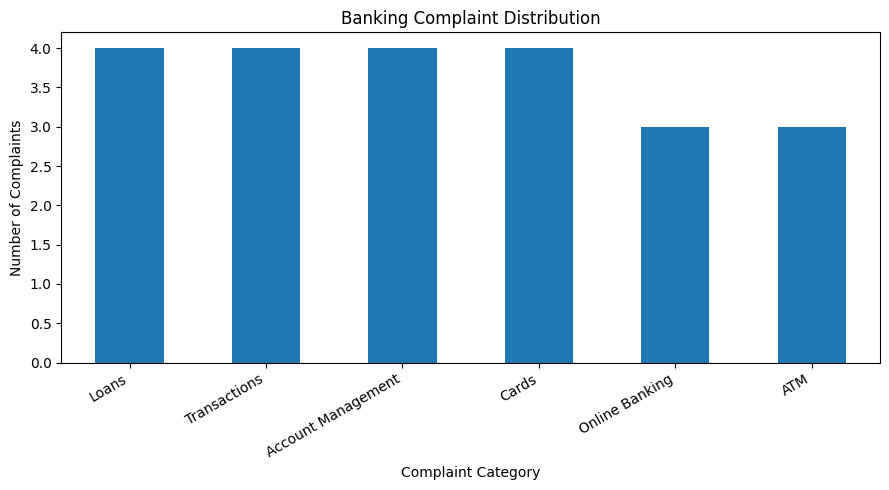

In [8]:
plt.figure(figsize=(9, 5))
category_count.plot(kind='bar')
plt.title('Banking Complaint Distribution')
plt.xlabel('Complaint Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [9]:
def predict_complaint(complaint):
    cleaned = preprocess_text(complaint)
    complaint_vector = vectorizer.transform([cleaned])
    prediction = model.predict(complaint_vector)[0]
    probabilities = model.predict_proba(complaint_vector)[0]
    confidence = max(probabilities) * 100
    return prediction, confidence

test_complaint = 'My ATM transaction failed and money was deducted from my account'
category, confidence = predict_complaint(test_complaint)

print('Complaint:', test_complaint)
print('Predicted Category:', category)
print('Confidence:', round(confidence, 2), '%')

Complaint: My ATM transaction failed and money was deducted from my account
Predicted Category: ATM
Confidence: 25.34 %


In [10]:
user_complaint = input('Enter a banking complaint: ')
category, confidence = predict_complaint(user_complaint)

print('\n----- RESULT -----')
print('Complaint:', user_complaint)
print('Predicted Category:', category)
print('Confidence:', round(confidence, 2), '%')

Enter a banking complaint: 2

----- RESULT -----
Complaint: 2
Predicted Category: Transactions
Confidence: 19.01 %


In [11]:
print('==============================')
print('BANKING COMPLAINT ANALYTICAL REPORT')
print('==============================')
print('Total Complaints:', len(df))
print('Number of Categories:', df['category'].nunique())
print('\nComplaint Distribution:')

for category, count in category_count.items():
    percentage = (count / len(df)) * 100
    print(f'{category}: {count} complaints ({percentage:.2f}%)')

print('\nMost Common Banking Problem:', most_common)
print('Model Accuracy:', round(accuracy * 100, 2), '%')

BANKING COMPLAINT ANALYTICAL REPORT
Total Complaints: 22
Number of Categories: 6

Complaint Distribution:
Loans: 4 complaints (18.18%)
Transactions: 4 complaints (18.18%)
Account Management: 4 complaints (18.18%)
Cards: 4 complaints (18.18%)
Online Banking: 3 complaints (13.64%)
ATM: 3 complaints (13.64%)

Most Common Banking Problem: Loans
Model Accuracy: 66.67 %
